In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 📊 Renewable Energy Consumption Analysis (1973–2024)

### An Exploratory Data Analysis (EDA) and Machine Learning Approach

This project explores renewable energy consumption trends across sectors and sources from **1973 to 2024**.  
We use **visualizations, correlation analysis, and predictive modeling (Linear Regression, Polynomial Regression, Random Forest, etc.)** to analyze growth patterns and forecast renewable energy usage.  


### Data load And Data Clean 

In [2]:
df=pd.read_csv('Dataset en.csv')

In [3]:
df.head()

,Year,Month,Sector,Hydroelectric Power,Geothermal Energy,Solar Energy,Wind Energy,Wood Energy,Waste Energy,"Fuel Ethanol, Excluding Denaturant",Biomass Losses and Co-products,Biomass Energy,Total Renewable Energy,Renewable Diesel Fuel,Other Biofuels,Conventional Hydroelectric Power,Biodiesel
0,1973,1,Commerical,0.00,0.00,0.0,0.0,0.570,0.000,0.0,0.0,0.570,0.570,0.0,0.0,0.000,0.0
1,1973,1,Electric Power,0.00,0.49,0.0,0.0,0.054,0.157,0.0,0.0,0.211,89.223,0.0,0.0,88.522,0.0
2,1973,1,Industrial,1.04,0.00,0.0,0.0,98.933,0.000,0.0,0.0,98.933,99.973,0.0,0.0,0.000,0.0
3,1973,1,Residential,0.00,0.00,0.0,0.0,30.074,0.000,0.0,0.0,0.000,30.074,0.0,0.0,0.000,0.0
4,1973,1,Transportation,0.00,0.00,0.0,0.0,0.000,0.000,0.0,0.0,0.000,0.000,0.0,0.0,0.000,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3065 entries, 0 to 3064
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Year                                3065 non-null   int64  
 1   Month                               3065 non-null   int64  
 2   Sector                              3065 non-null   object 
 3   Hydroelectric Power                 3065 non-null   float64
 4   Geothermal Energy                   3065 non-null   float64
 5   Solar Energy                        3065 non-null   float64
 6   Wind Energy                         3065 non-null   float64
 7   Wood Energy                         3065 non-null   float64
 8   Waste Energy                        3065 non-null   float64
 9   Fuel Ethanol, Excluding Denaturant  3065 non-null   float64
 10  Biomass Losses and Co-products      3065 non-null   float64
 11  Biomass Energy                      3065 no

In [5]:
df.describe()

,Year,Month,Hydroelectric Power,Geothermal Energy,Solar Energy,Wind Energy,Wood Energy,Waste Energy,"Fuel Ethanol, Excluding Denaturant",Biomass Losses and Co-products,Biomass Energy,Total Renewable Energy,Renewable Diesel Fuel,Other Biofuels,Conventional Hydroelectric Power,Biodiesel
count,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000
mean,1998.042414,6.491028,0.169759,1.146369,2.015008,4.282404,36.644408,5.820124,6.976648,4.834706,46.285969,70.872209,0.428949,0.031752,15.757374,0.953720
std,14.747378,3.456934,0.373819,1.550857,5.774511,18.124793,46.900639,8.247359,21.911920,15.601717,64.241520,71.197761,2.687850,0.258149,32.134059,3.985003
min,1973.000000,1.000000,-0.002000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1985.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.483000,0.000000,0.000000,0.000000,0.258000,2.070000,0.000000,0.000000,0.000000,0.000000
50%,1998.000000,6.000000,0.000000,0.357000,0.004000,0.000000,12.062000,0.108000,0.007000,0.000000,9.716000,50.984000,0.000000,0.000000,0.000000,0.000000
75%,2011.000000,9.000000,0.036000,1.673000,0.774000,0.001000,51.808000,12.764000,1.283000,0.000000,89.359000,126.982000,0.000000,0.000000,0.000000,0.000000
max,2024.000000,12.000000,2.047000,5.951000,64.040000,157.409000,183.628000,32.875000,104.420000,75.373000,233.200000,308.175000,38.344000,4.101000,117.453000,27.871000


In [6]:
# data clean 
df.isnull().sum()

Year                                  0
Month                                 0
Sector                                0
Hydroelectric Power                   0
Geothermal Energy                     0
Solar Energy                          0
Wind Energy                           0
Wood Energy                           0
Waste Energy                          0
Fuel Ethanol, Excluding Denaturant    0
Biomass Losses and Co-products        0
Biomass Energy                        0
Total Renewable Energy                0
Renewable Diesel Fuel                 0
Other Biofuels                        0
Conventional Hydroelectric Power      0
Biodiesel                             0
dtype: int64

In [7]:
# check duplicates
df.duplicated()
print(df.duplicated().sum())

0


In [8]:
df.shape

(3065, 17)

In [9]:
df.columns

Index(['Year', 'Month', 'Sector', 'Hydroelectric Power', 'Geothermal Energy',
       'Solar Energy', 'Wind Energy', 'Wood Energy', 'Waste Energy',
       'Fuel Ethanol, Excluding Denaturant', 'Biomass Losses and Co-products',
       'Biomass Energy', 'Total Renewable Energy', 'Renewable Diesel Fuel',
       'Other Biofuels', 'Conventional Hydroelectric Power', 'Biodiesel'],
      dtype='object')

In [10]:
df.describe()

,Year,Month,Hydroelectric Power,Geothermal Energy,Solar Energy,Wind Energy,Wood Energy,Waste Energy,"Fuel Ethanol, Excluding Denaturant",Biomass Losses and Co-products,Biomass Energy,Total Renewable Energy,Renewable Diesel Fuel,Other Biofuels,Conventional Hydroelectric Power,Biodiesel
count,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000,3065.000000
mean,1998.042414,6.491028,0.169759,1.146369,2.015008,4.282404,36.644408,5.820124,6.976648,4.834706,46.285969,70.872209,0.428949,0.031752,15.757374,0.953720
std,14.747378,3.456934,0.373819,1.550857,5.774511,18.124793,46.900639,8.247359,21.911920,15.601717,64.241520,71.197761,2.687850,0.258149,32.134059,3.985003
min,1973.000000,1.000000,-0.002000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1985.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.483000,0.000000,0.000000,0.000000,0.258000,2.070000,0.000000,0.000000,0.000000,0.000000
50%,1998.000000,6.000000,0.000000,0.357000,0.004000,0.000000,12.062000,0.108000,0.007000,0.000000,9.716000,50.984000,0.000000,0.000000,0.000000,0.000000
75%,2011.000000,9.000000,0.036000,1.673000,0.774000,0.001000,51.808000,12.764000,1.283000,0.000000,89.359000,126.982000,0.000000,0.000000,0.000000,0.000000
max,2024.000000,12.000000,2.047000,5.951000,64.040000,157.409000,183.628000,32.875000,104.420000,75.373000,233.200000,308.175000,38.344000,4.101000,117.453000,27.871000


In [11]:
# check Duplicated Rows before 
before=df.shape
print(f"show before check duplicate {before}")
# Now check Duplicate 
df.duplicated().sum()
print(f"Check Duplicate{df.duplicated()}")
# After Duplicate
after=df.shape
print(f"show before check duplicate {after}")


show before check duplicate (3065, 17)
Check Duplicate0       False
1       False
2       False
3       False
4       False
        ...  
3060    False
3061    False
3062    False
3063    False
3064    False
Length: 3065, dtype: bool
show before check duplicate (3065, 17)


### EDA

In [12]:
print(df['Total Renewable Energy'].describe())

count    3065.000000
mean       70.872209
std        71.197761
min         0.000000
25%         2.070000
50%        50.984000
75%       126.982000
max       308.175000
Name: Total Renewable Energy, dtype: float64


In [13]:
print(df['Sector'].describe())


count           3065
unique             5
top       Commerical
freq             613
Name: Sector, dtype: object


## Total Renewable Energy Over Years

We visualize the overall trend of **total renewable energy consumption** across all years.


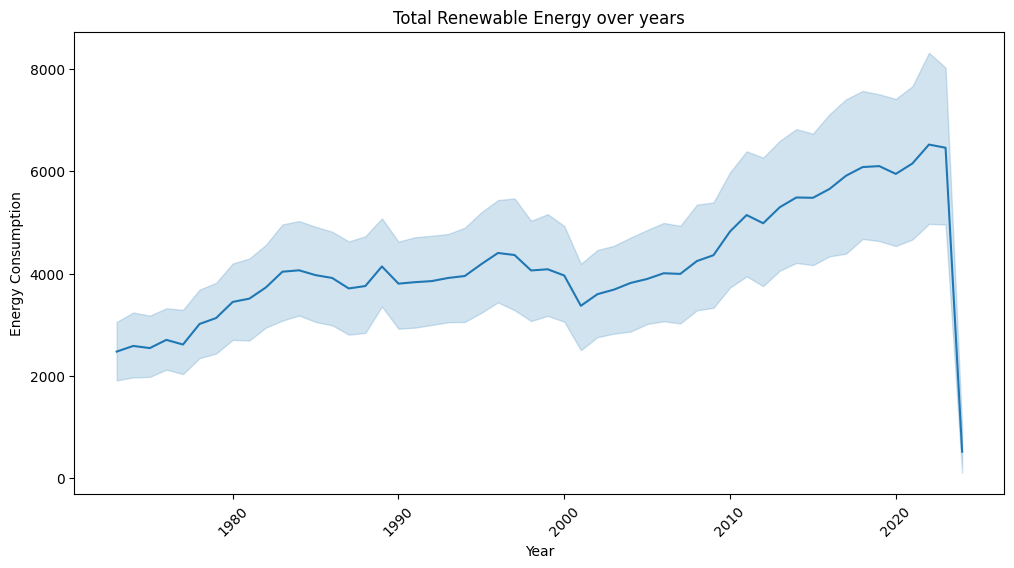

In [14]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df,x='Year',y='Total Renewable Energy',estimator='sum')
plt.title('Total Renewable Energy over years')
plt.xticks(rotation=45)
plt.ylabel('Energy Consumption')
plt.show()

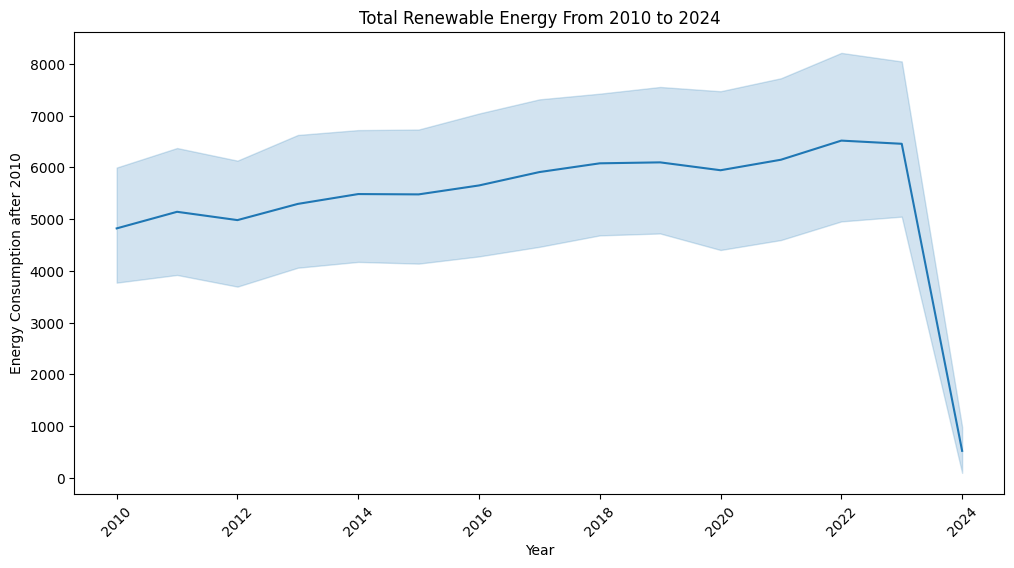

In [15]:
# Energy Consumption after 2010 because its high after 2010
df_yearby=df[df['Year']>=2010]  # make an variable df_yearby 
plt.figure(figsize=(12,6))
sns.lineplot(data=df_yearby,x='Year',y='Total Renewable Energy',estimator='sum')
plt.title('Total Renewable Energy From 2010 to 2024')
plt.xticks(rotation=45)
plt.ylabel('Energy Consumption after 2010')
plt.show()

### Sector wise Use of Energy Year by Year

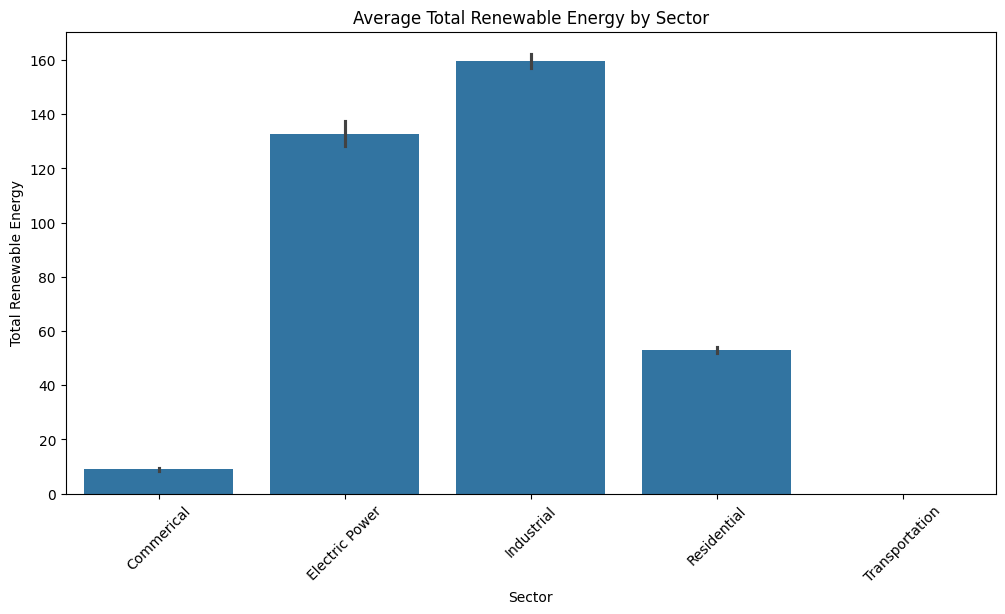

In [16]:
# print Total Renewable Energy by Sector
plt.figure(figsize=(12,6))
sns.barplot(data=df,x='Sector',y='Total Renewable Energy',estimator='mean')
plt.title('Average Total Renewable Energy by Sector')
plt.xticks(rotation=45)
plt.show()

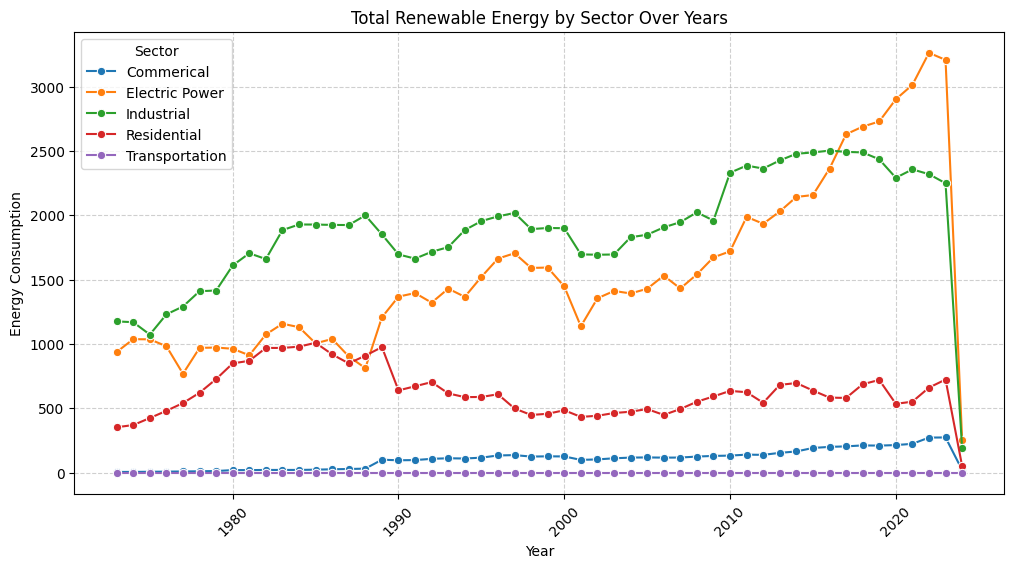

In [17]:
# Group by Year and Sector
year_sector = df.groupby(['Year','Sector'])['Total Renewable Energy'].sum().reset_index() # groupby function use and value store in variable 
# Plot
plt.figure(figsize=(12,6))
sns.lineplot(data=year_sector, x='Year', y='Total Renewable Energy', hue='Sector', marker="o")
plt.title('Total Renewable Energy by Sector Over Years')
plt.xticks(rotation=45)
plt.ylabel('Energy Consumption')
plt.legend(title='Sector')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


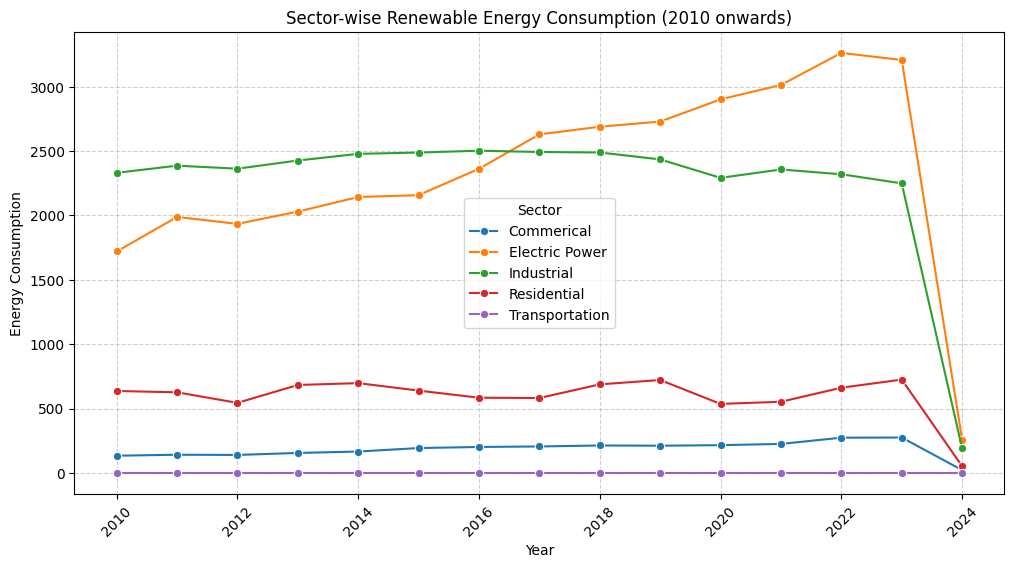

In [18]:
# Filter data after 2010
year_sector = df.groupby(['Year','Sector'])['Total Renewable Energy'].sum().reset_index()
year_sector = year_sector[year_sector['Year'] >= 2010]

# Plot
plt.figure(figsize=(12,6))
sns.lineplot(data=year_sector, x='Year', y='Total Renewable Energy', hue='Sector', marker="o")
plt.title('Sector-wise Renewable Energy Consumption (2010 onwards)')
plt.xticks(rotation=45)
plt.ylabel('Energy Consumption')
plt.legend(title='Sector')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


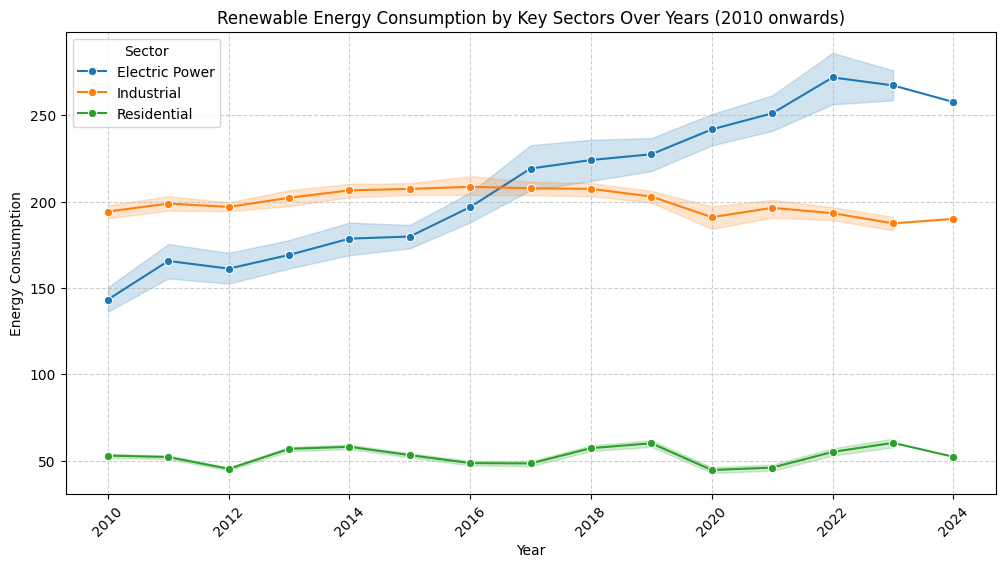

In [19]:
# make plot Sector electric power, industrial, Residential after 2010

sectors_of_interest = ['Electric Power', 'Industrial', 'Residential'] # make variable 
df_sectors = df[df['Sector'].isin(sectors_of_interest) & (df['Year'] >= 2010)] # variable 

plt.figure(figsize=(12,6))
sns.lineplot(data=df_sectors, x='Year', y='Total Renewable Energy', hue='Sector', marker="o")
plt.title('Renewable Energy Consumption by Key Sectors Over Years (2010 onwards)')
plt.xticks(rotation=45)
plt.ylabel('Energy Consumption')
plt.legend(title='Sector')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


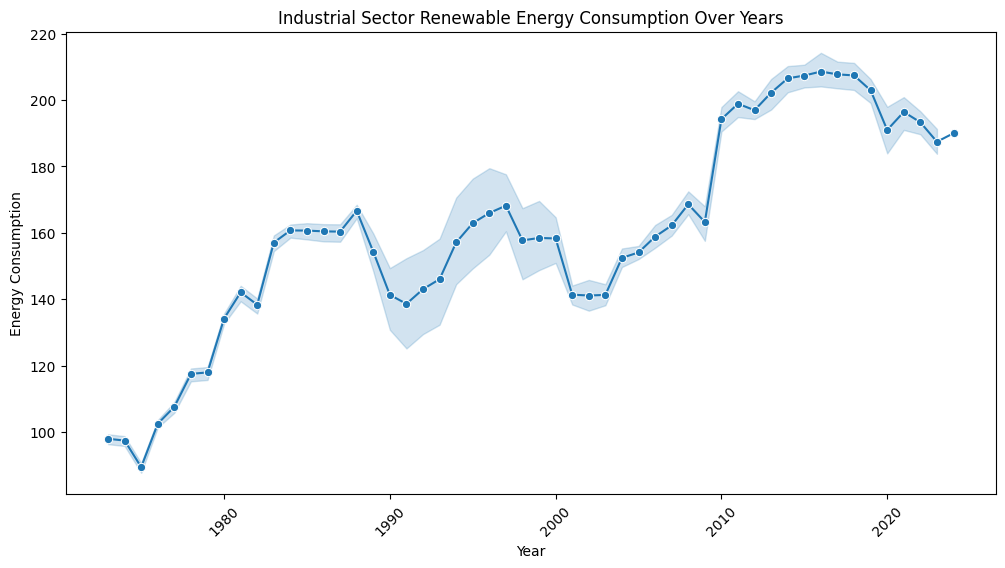

In [20]:
# Industrial Sector Use of Energy Year by Year
df_industrial = df[df['Sector'] == 'Industrial']
plt.figure(figsize=(12,6))
sns.lineplot(data=df_industrial, x='Year', y='Total Renewable Energy', marker="o")
plt.title('Industrial Sector Renewable Energy Consumption Over Years')
plt.xticks(rotation=45)
plt.ylabel('Energy Consumption')
plt.show()

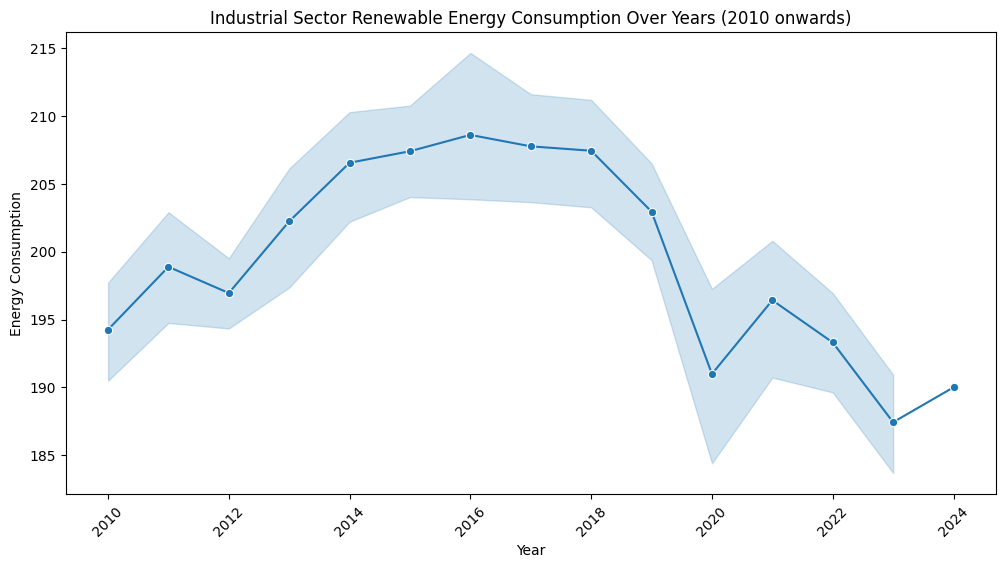

In [21]:
# Industrial Sector Use of Energy after 2010
df_industrial = df[(df['Sector'] == 'Industrial') & (df['Year'] >= 2010)]
plt.figure(figsize=(12,6))
sns.lineplot(data=df_industrial, x='Year', y='Total Renewable Energy', marker="o")
plt.title('Industrial Sector Renewable Energy Consumption Over Years (2010 onwards)')
plt.xticks(rotation=45)
plt.ylabel('Energy Consumption')
plt.show()

## Industrial Sector – Energy Source Consumption Over Years

We filter the dataset for the **Industrial sector** and reshape it to analyze how different energy sources are consumed over time.


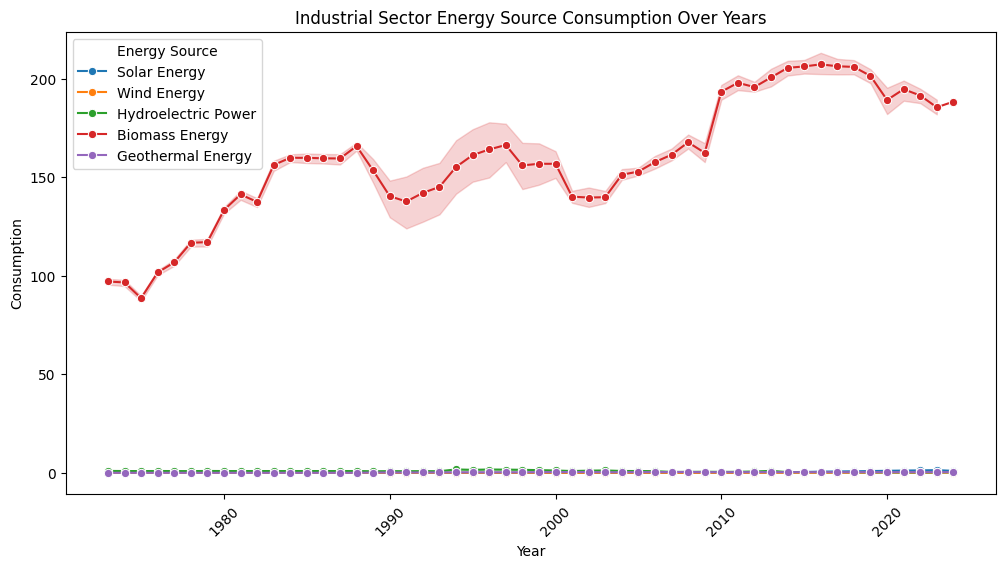

In [22]:
# which energy source use industrial sector
df_industrial_sources = df[df['Sector'] == 'Industrial']
df_industrial_sources = df_industrial_sources.melt(
	id_vars=['Year', 'Sector'],
	value_vars=['Solar Energy', 'Wind Energy', 'Hydroelectric Power', 'Biomass Energy', 'Geothermal Energy'],
	var_name='Energy Source',
	value_name='Consumption'
)
plt.figure(figsize=(12,6))
sns.lineplot(data=df_industrial_sources, x='Year', y='Consumption', hue='Energy Source', marker="o")
plt.title('Industrial Sector Energy Source Consumption Over Years')
plt.xticks(rotation=45)
plt.ylabel('Consumption')
plt.show()

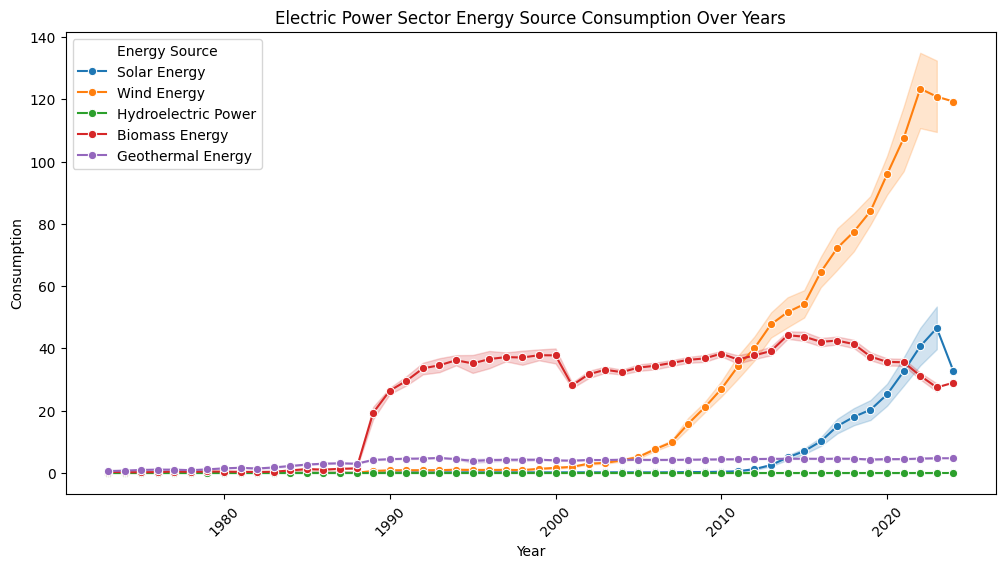

In [23]:
df_industrial_sources = df[df['Sector'] == 'Electric Power']
df_industrial_sources = df_industrial_sources.melt(
	id_vars=['Year', 'Sector'],
	value_vars=['Solar Energy', 'Wind Energy', 'Hydroelectric Power', 'Biomass Energy', 'Geothermal Energy'],
	var_name='Energy Source',
	value_name='Consumption'
)
plt.figure(figsize=(12,6))
sns.lineplot(data=df_industrial_sources, x='Year', y='Consumption', hue='Energy Source', marker="o")
plt.title('Electric Power Sector Energy Source Consumption Over Years')
plt.xticks(rotation=45)
plt.ylabel('Consumption')
plt.show()

In [24]:
df.Sector



0           Commerical
1       Electric Power
2           Industrial
3          Residential
4       Transportation
             ...      
3060        Commerical
3061    Electric Power
3062        Industrial
3063       Residential
3064    Transportation
Name: Sector, Length: 3065, dtype: object

In [25]:
df.columns

Index(['Year', 'Month', 'Sector', 'Hydroelectric Power', 'Geothermal Energy',
       'Solar Energy', 'Wind Energy', 'Wood Energy', 'Waste Energy',
       'Fuel Ethanol, Excluding Denaturant', 'Biomass Losses and Co-products',
       'Biomass Energy', 'Total Renewable Energy', 'Renewable Diesel Fuel',
       'Other Biofuels', 'Conventional Hydroelectric Power', 'Biodiesel'],
      dtype='object')

In [26]:
df.dtypes

Year                                    int64
Month                                   int64
Sector                                 object
Hydroelectric Power                   float64
Geothermal Energy                     float64
Solar Energy                          float64
Wind Energy                           float64
Wood Energy                           float64
Waste Energy                          float64
Fuel Ethanol, Excluding Denaturant    float64
Biomass Losses and Co-products        float64
Biomass Energy                        float64
Total Renewable Energy                float64
Renewable Diesel Fuel                 float64
Other Biofuels                        float64
Conventional Hydroelectric Power      float64
Biodiesel                             float64
dtype: object

In [27]:
df.Sector


0           Commerical
1       Electric Power
2           Industrial
3          Residential
4       Transportation
             ...      
3060        Commerical
3061    Electric Power
3062        Industrial
3063       Residential
3064    Transportation
Name: Sector, Length: 3065, dtype: object

In [28]:
df.Month

0       1
1       1
2       1
3       1
4       1
       ..
3060    1
3061    1
3062    1
3063    1
3064    1
Name: Month, Length: 3065, dtype: int64

## Total Renewable Energy by Year

We sum up all renewable energy sources by year and plot the overall trends to observe how energy production has changed over time.


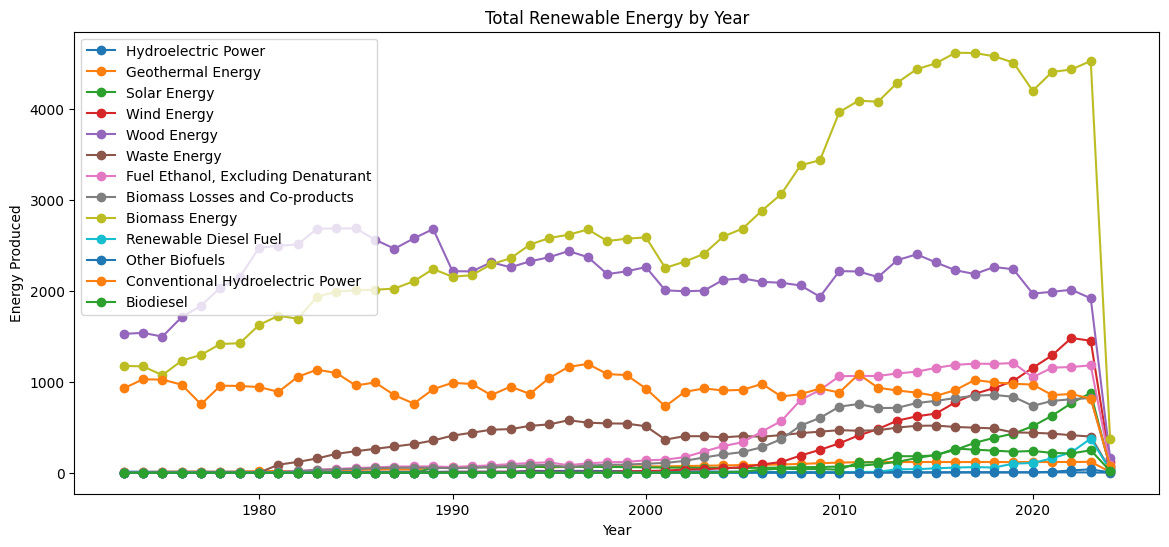

In [37]:
# make a line plot energy col over years
yearly_total = df.groupby('Year')[energy_col].sum()
yearly_total.head()
yearly_total.plot(kind='line', figsize=(14,6), marker='o', title='Total Renewable Energy by Year')
plt.ylabel('Energy Produced')
plt.show()

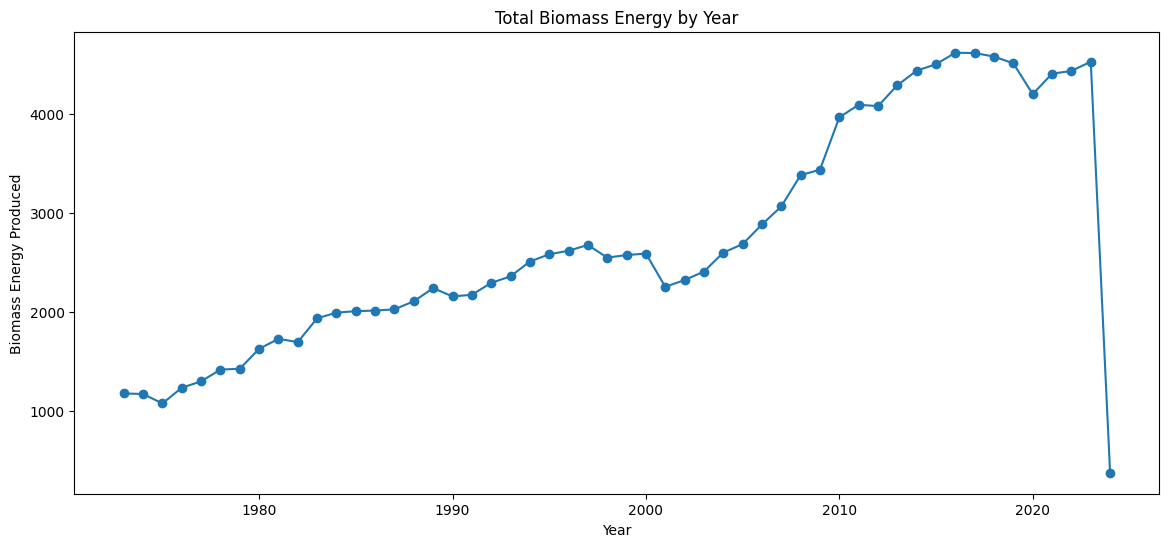

In [30]:
# make plot of biomass energy over years
yearly_biomass = df.groupby('Year')['Biomass Energy'].sum()
yearly_biomass.plot(kind='line', figsize=(14,6), marker='o', title='Total Biomass Energy by Year')
plt.ylabel('Biomass Energy Produced')
plt.show()

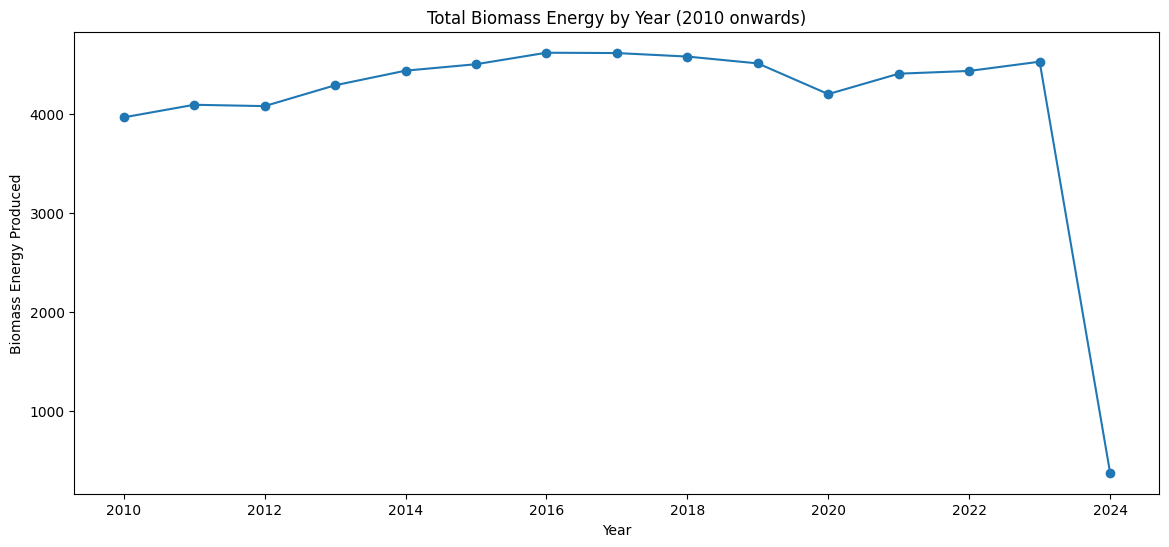

In [33]:
# make plot of biomass energy after 2010
yearly_biomass = df[df['Year']>=2010].groupby('Year')['Biomass Energy'].sum()
yearly_biomass.plot(kind='line', figsize=(14,6), marker='o', title='Total Biomass Energy by Year (2010 onwards)')
plt.ylabel('Biomass Energy Produced')
plt.show()

## Energy Sources Consumption by Sector Over Years

We group the dataset by **Year** and **Sector** to explore how different renewable energy sources are consumed across sectors over time. Each line represents a combination of **energy source** and **sector**.


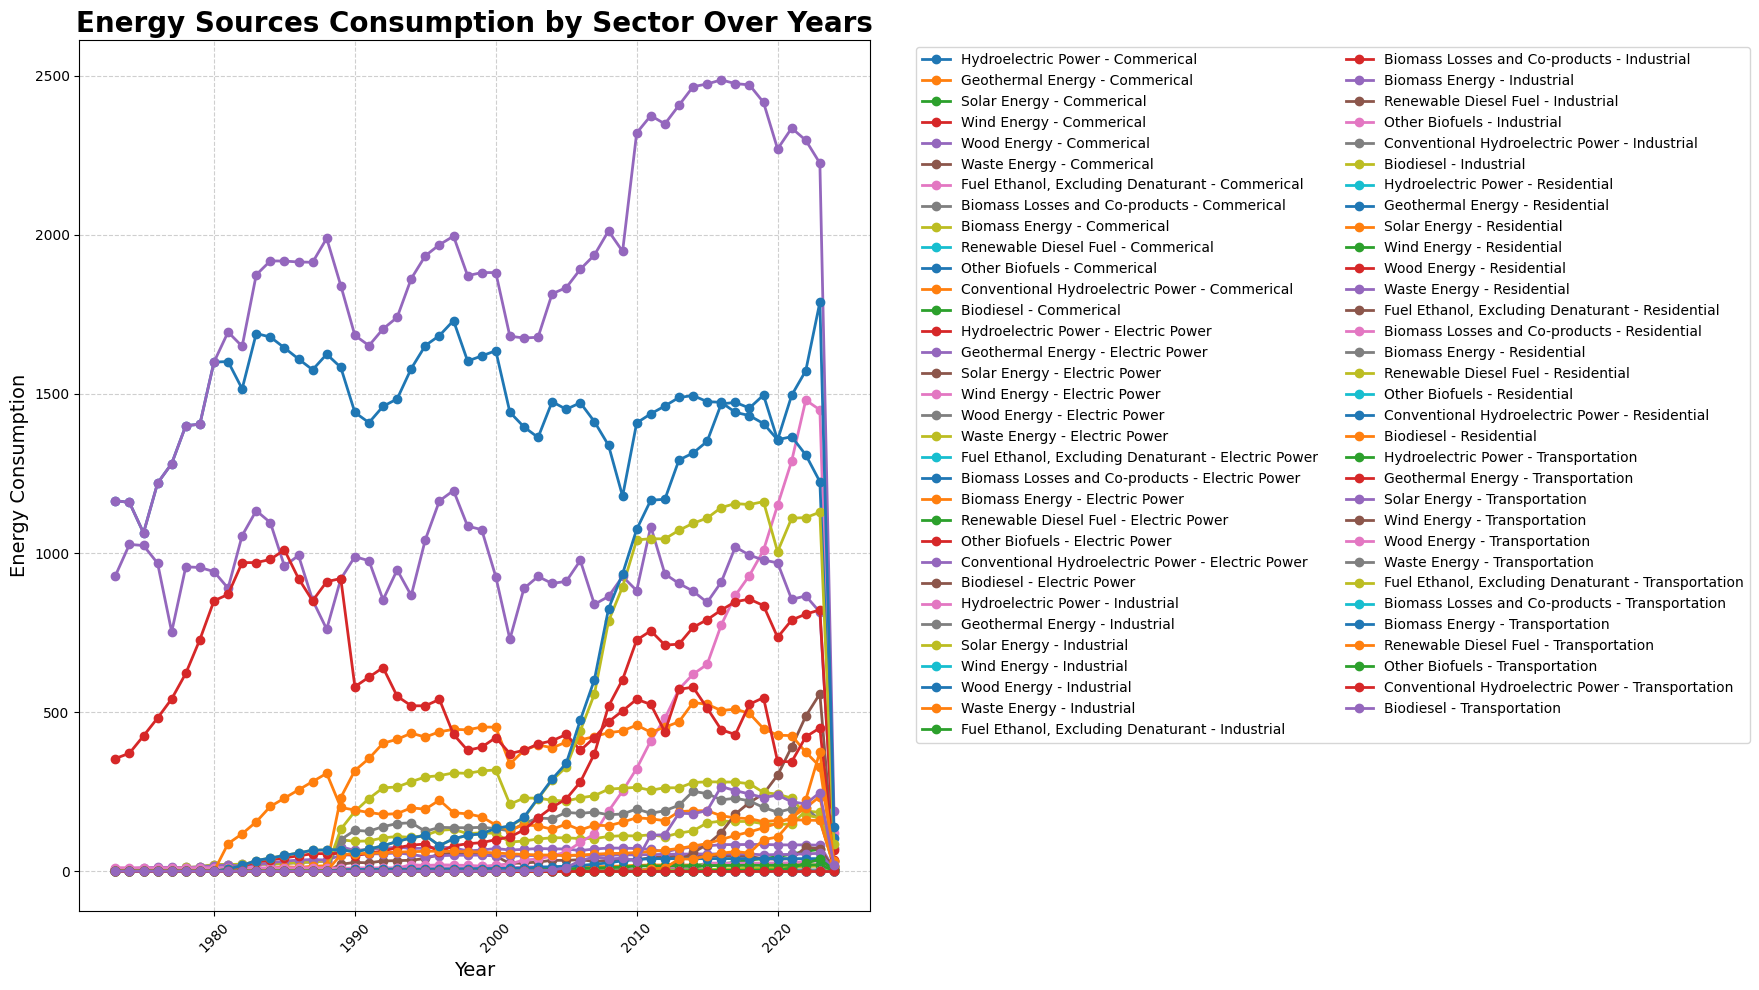

In [36]:
# Create a DataFrame grouped by Year and Sector, summing all energy columns
year_sector_source = df.groupby(['Year', 'Sector'])[energy_col].sum().reset_index()

plt.figure(figsize=(18,10))

# Loop through each sector
for sector in year_sector_source['Sector'].unique():
    subset = year_sector_source[year_sector_source['Sector'] == sector]
    
    # Loop through each energy source in energy_col 
    for col in energy_col:
        plt.plot(
            subset['Year'], subset[col], 
            marker="o", linewidth=2, 
            label=f"{col} - {sector}"
        )

plt.title('Energy Sources Consumption by Sector Over Years', fontsize=20, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Energy Consumption', fontsize=14)

# Legend outside to avoid clutter
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", ncol=2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Energy Sources Over Time (1973–2024)

We plot the yearly trends of different renewable energy sources to analyze how consumption has evolved across sectors.


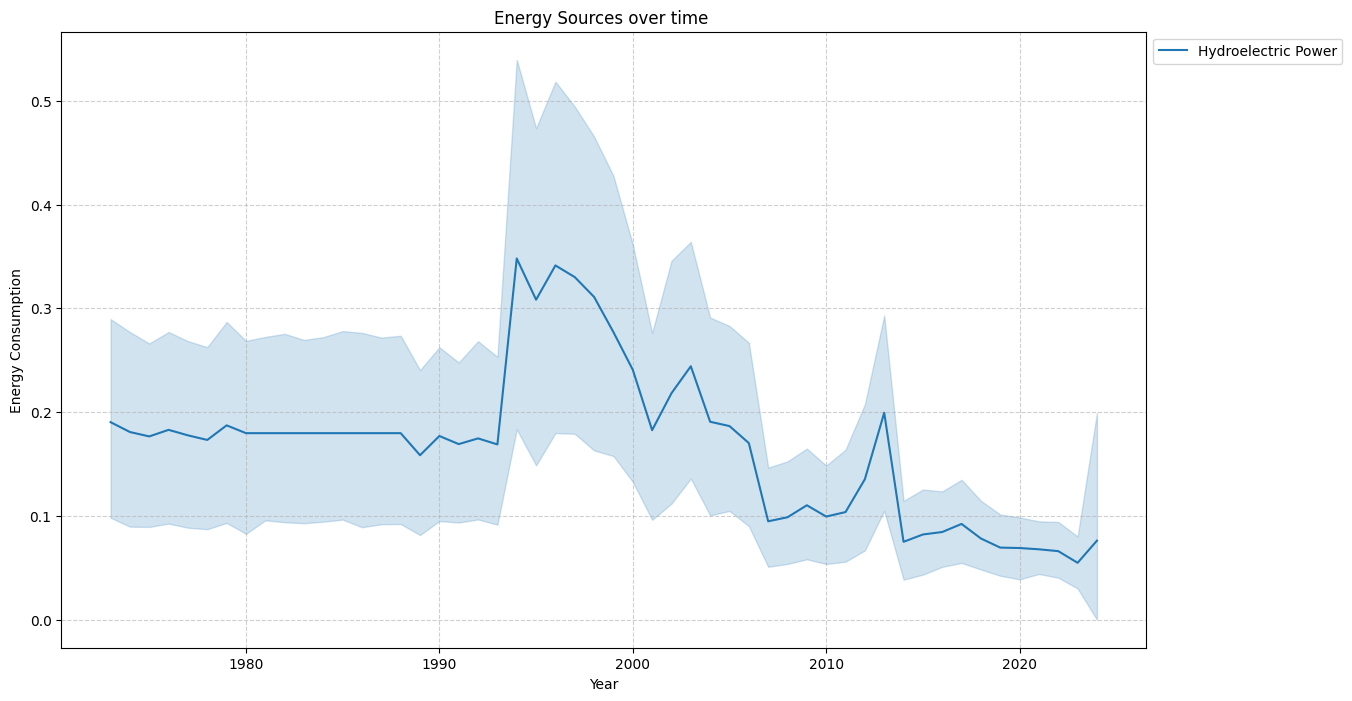

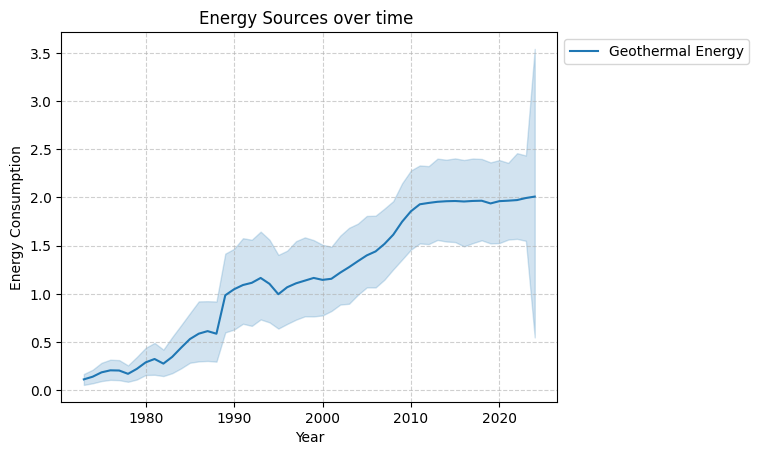

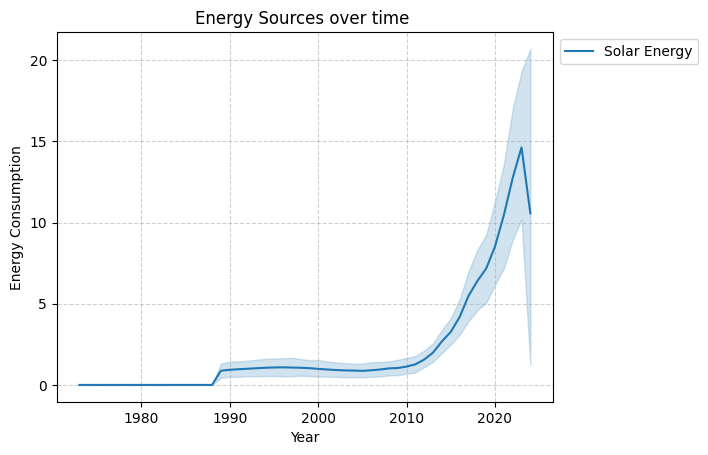

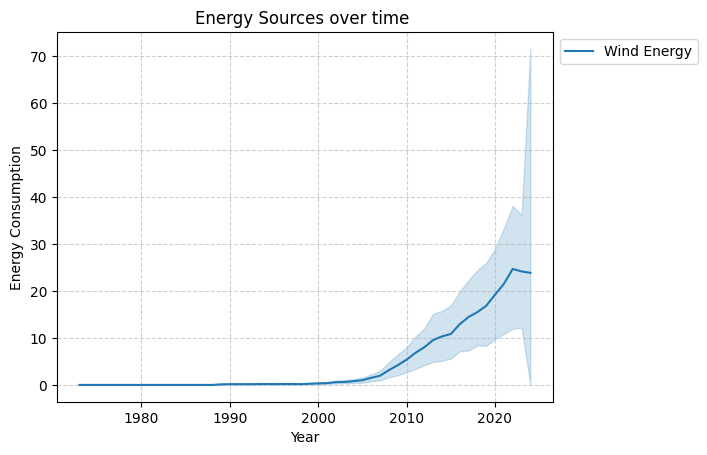

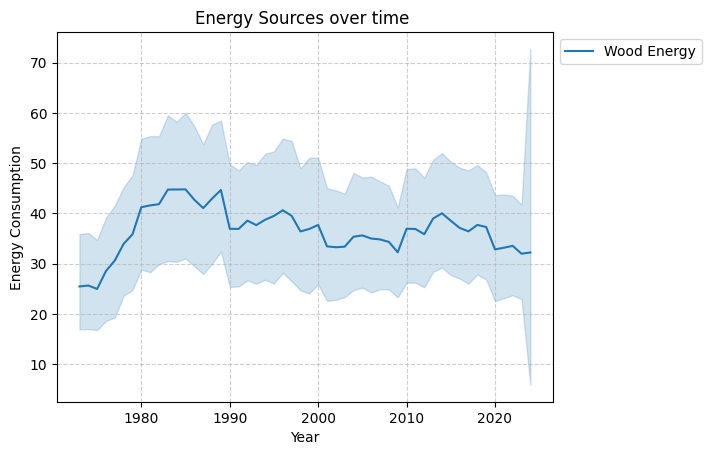

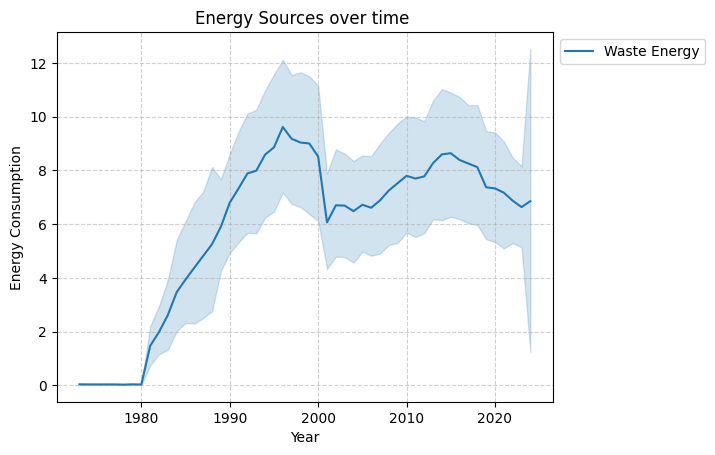

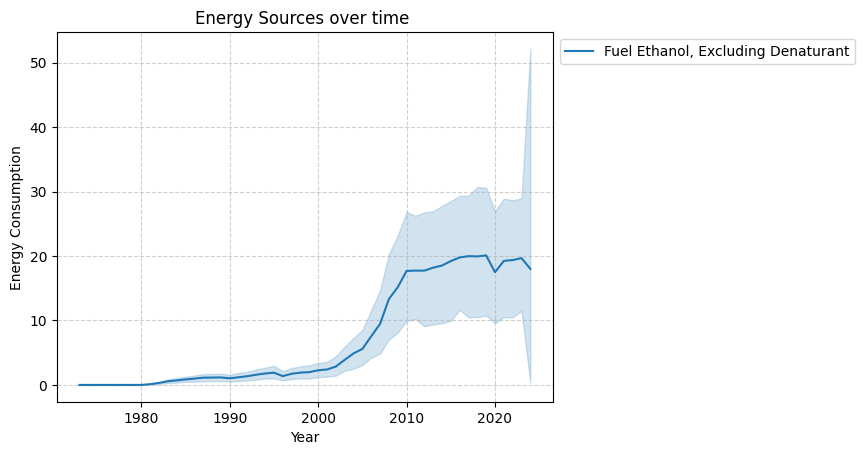

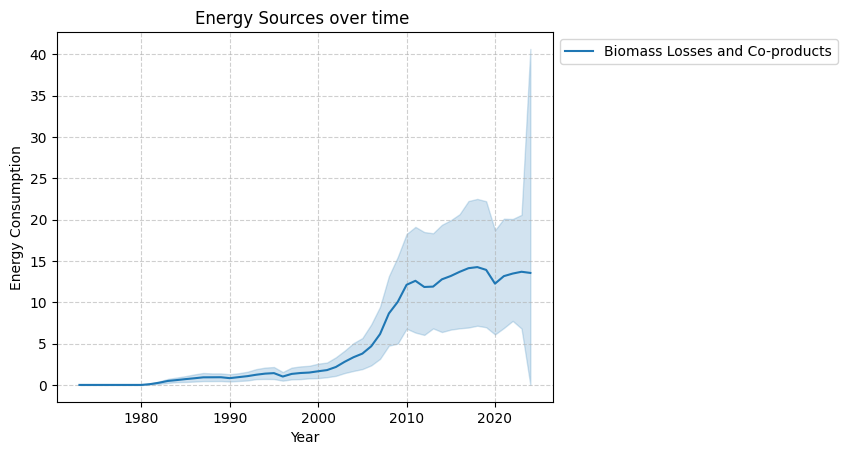

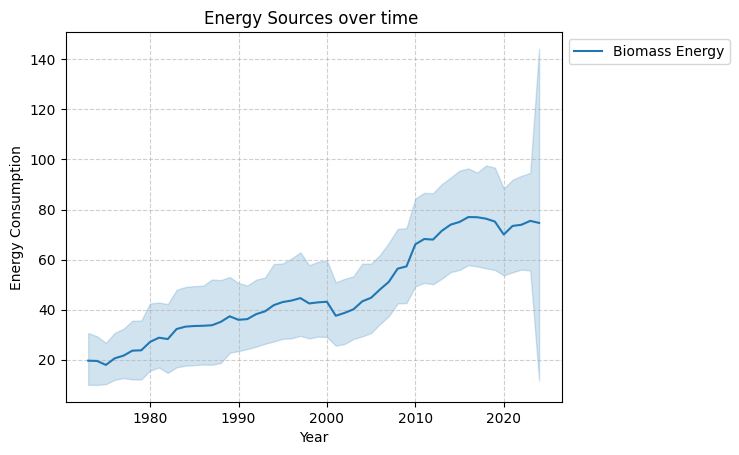

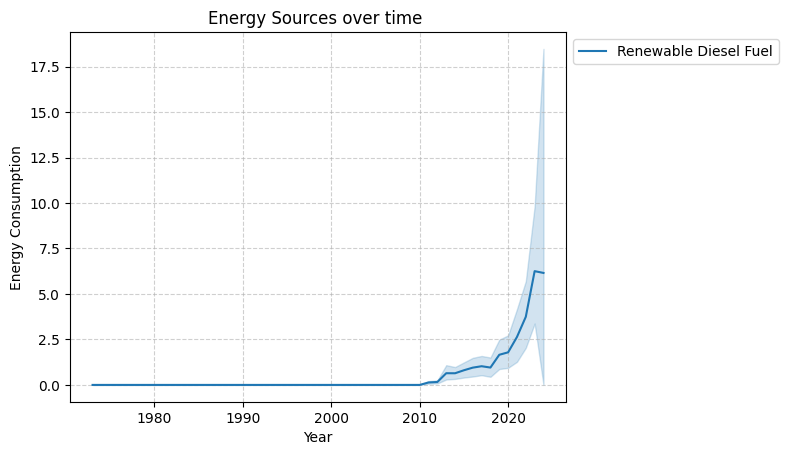

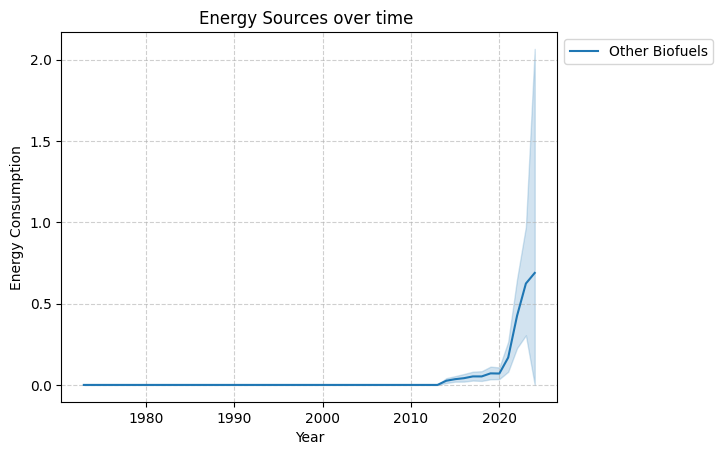

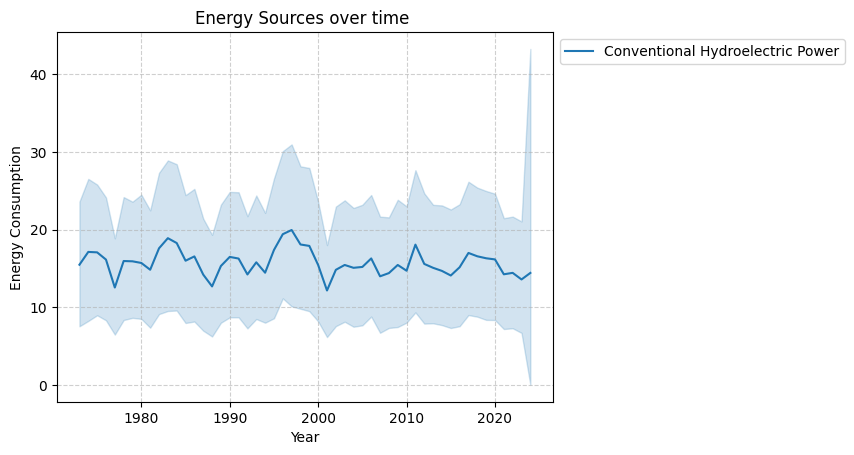

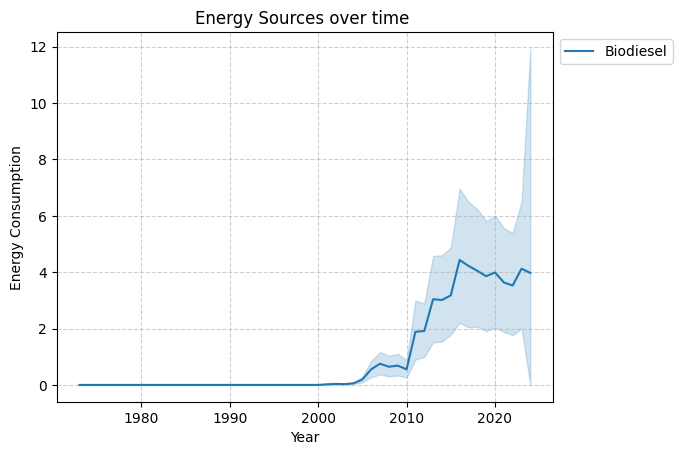

In [35]:
energy_col=[
    'Hydroelectric Power', 'Geothermal Energy',
       'Solar Energy', 'Wind Energy', 'Wood Energy', 'Waste Energy',
       'Fuel Ethanol, Excluding Denaturant', 'Biomass Losses and Co-products',
       'Biomass Energy', 'Renewable Diesel Fuel',
       'Other Biofuels', 'Conventional Hydroelectric Power', 'Biodiesel'
]
plt.figure(figsize=(14,8))
for col in energy_col:
    sns.lineplot(data=df,x='Year',y=col, label=col)
    
    plt.title("Energy Sources over time ")
    plt.ylabel("Energy Consumption")
    plt.xlabel("Year")
    plt.legend(loc="upper left",bbox_to_anchor=(1,1))
    plt.grid(True,linestyle="--",alpha=0.6)
    plt.show()

## Correlation Heatmap of Energy Sources

To understand the relationships between different renewable energy sources, we plot a **correlation heatmap** using Seaborn. This helps identify which energy sources move together and how strongly they are related.


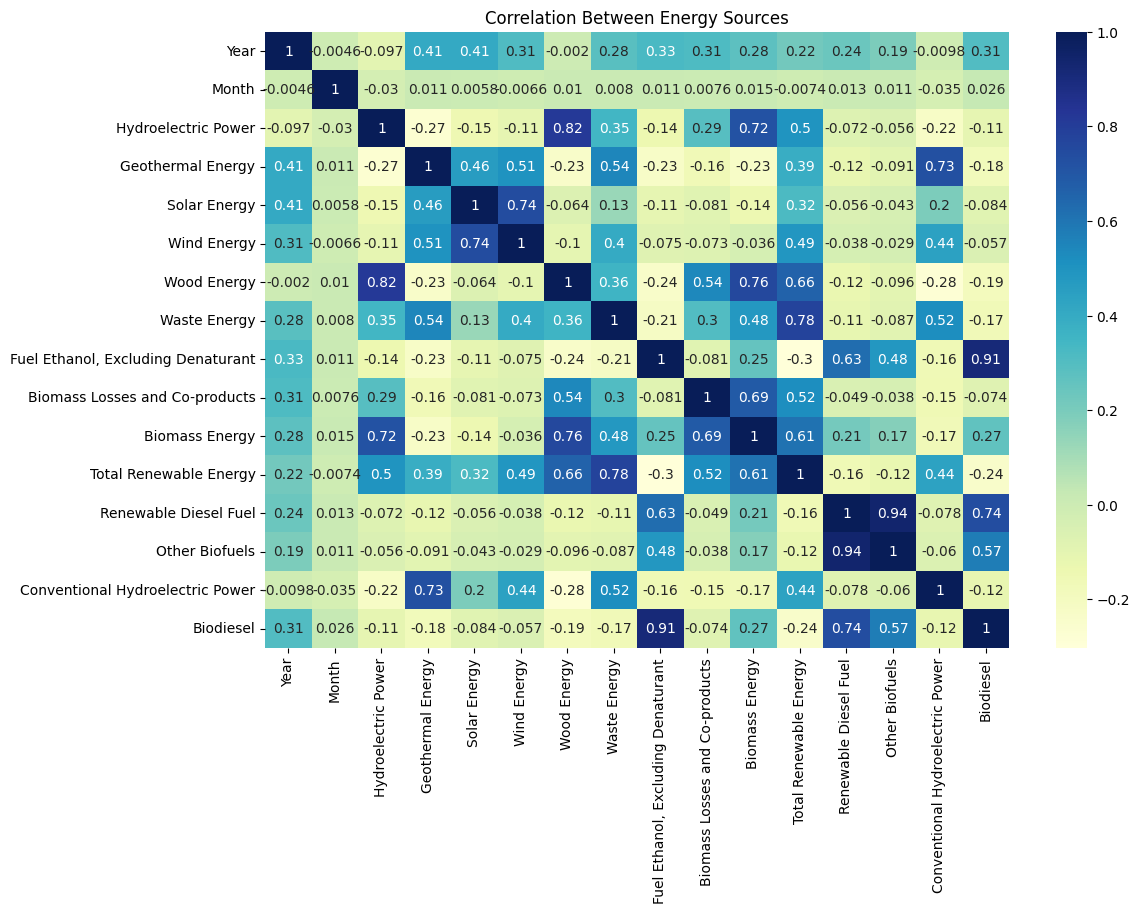

In [38]:
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.title('Correlation Between Energy Sources')
plt.show()


## Interactive Pie Chart of Total Energy Use by Sector

We visualize the contribution of each renewable energy sector to the overall total using a **Plotly pie chart**.


In [39]:

import plotly.express as px
# Assuming your dataframe is named df and already loaded
energy_sectors = ['Solar Energy', 'Wind Energy', 'Biomass Energy', 'Geothermal Energy', 'Hydroelectric Power', 'Wood Energy','Waste Energy','Fuel Ethanol, Excluding Denaturant', 'Biomass Losses and Co-products']

# Sum total energy by sector
sector_totals = df[energy_sectors].sum().reset_index()
sector_totals.columns = ['Sector', 'Total Energy']

# Create interactive pie chart
fig = px.pie(sector_totals,
             names='Sector',
             values='Total Energy',
             title='Total Energy Use by Sector',
             hole=0.3)  # Optional: make it a donut chart

fig.update_traces(textinfo='percent+label', hoverinfo='label+percent+value')
fig.show()


In [40]:
# Create a 'Date' column from 'Year' and 'Month'
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))
print(df.head())

   Year  Month          Sector  Hydroelectric Power  Geothermal Energy  \
0  1973      1      Commerical                 0.00               0.00   
1  1973      1  Electric Power                 0.00               0.49   
2  1973      1      Industrial                 1.04               0.00   
3  1973      1     Residential                 0.00               0.00   
4  1973      1  Transportation                 0.00               0.00   

   Solar Energy  Wind Energy  Wood Energy  Waste Energy  \
0           0.0          0.0        0.570         0.000   
1           0.0          0.0        0.054         0.157   
2           0.0          0.0       98.933         0.000   
3           0.0          0.0       30.074         0.000   
4           0.0          0.0        0.000         0.000   

   Fuel Ethanol, Excluding Denaturant  Biomass Losses and Co-products  \
0                                 0.0                             0.0   
1                                 0.0                 

In [41]:
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str))
print(df['Date'].tail())

3060   2024-01-01
3061   2024-01-01
3062   2024-01-01
3063   2024-01-01
3064   2024-01-01
Name: Date, dtype: datetime64[ns]


In [42]:
for sector in energy_sectors:
    max_year = df.groupby('Year')[sector].sum().idxmax()
    min_year = df.groupby('Year')[sector].sum().idxmin()
    print(f"{sector}: Max in {max_year}, Min in {min_year}")
    


Solar Energy: Max in 2023, Min in 1973
Wind Energy: Max in 2022, Min in 1973
Biomass Energy: Max in 2016, Min in 2024
Geothermal Energy: Max in 2023, Min in 1973
Hydroelectric Power: Max in 1994, Min in 2024
Wood Energy: Max in 1985, Min in 2024
Waste Energy: Max in 1996, Min in 1978
Fuel Ethanol, Excluding Denaturant: Max in 2019, Min in 1973
Biomass Losses and Co-products: Max in 2018, Min in 1973


### Forcasting

In [43]:
# Grouping energy use by year
sector_yearly = df.groupby('Year')[energy_sectors].sum().reset_index()
print(sector_yearly.head())

   Year  Solar Energy  Wind Energy  Biomass Energy  Geothermal Energy  \
0  1973           0.0          0.0        1174.972              6.709   
1  1974           0.0          0.0        1168.709              8.368   
2  1975           0.0          0.0        1073.324             11.077   
3  1976           0.0          0.0        1231.743             12.340   
4  1977           0.0          0.0        1296.550             12.223   

   Hydroelectric Power  Wood Energy  Waste Energy  \
0               11.420     1527.016         2.055   
1               10.850     1537.761         1.902   
2               10.597     1496.929         1.806   
3               10.977     1711.487         1.889   
4               10.658     1836.521         1.808   

   Fuel Ethanol, Excluding Denaturant  Biomass Losses and Co-products  
0                                 0.0                             0.0  
1                                 0.0                             0.0  
2                         

## Linear Regression on Total Renewable Energy (1973–2024)

We aggregate the total renewable energy by year and apply a **Linear Regression** model to analyze the trend and evaluate performance.


Evaluation on entire dataset (1973–2024):
MAE: 506.4307188593848
RMSE: 853.6468912332502
R²: 0.4526417980483174


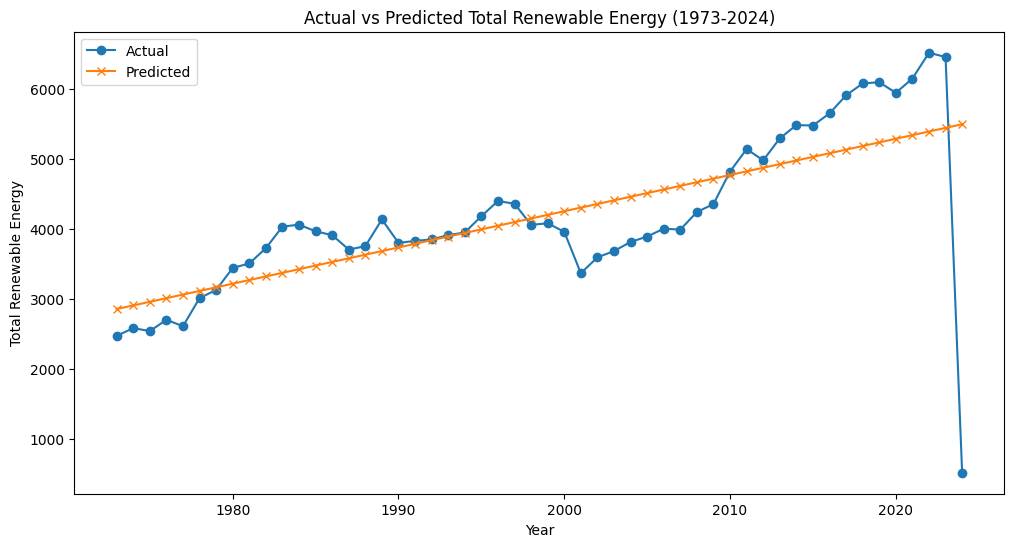

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Aggregate total renewable energy by year
df_total = df.groupby('Year', as_index=False)['Total Renewable Energy'].sum()

X = df_total[["Year"]]
y = df_total["Total Renewable Energy"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("Evaluation on entire dataset (1973–2024):")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
# plot actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(df_total['Year'], y, label='Actual', marker='o')
plt.plot(df_total['Year'], y_pred, label='Predicted', marker='x')
plt.title('Actual vs Predicted Total Renewable Energy (1973-2024)')
plt.xlabel('Year')
plt.ylabel('Total Renewable Energy')
plt.legend()
plt.show()

## Polynomial Regression on Total Renewable Energy (1973–2024)

To capture nonlinear trends, we apply a **Polynomial Regression** model (degree = 2 in this case). This helps model possible curvature in renewable energy growth over the years.


Polynomial Regression Results:
MAE: 507.2855505726063
RMSE: 853.1601206930488
R²: 0.4532658544015067


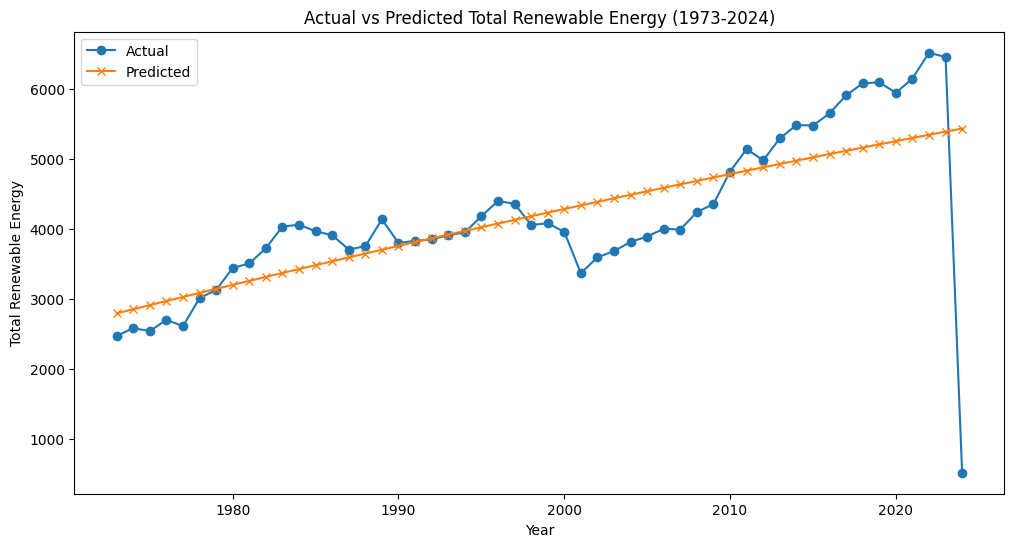

In [45]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Create polynomial features
poly = PolynomialFeatures(degree=2)  # try 2 or 3
X_poly = poly.fit_transform(df_total[["Year"]])

# Train polynomial regression
model_poly = LinearRegression()
model_poly.fit(X_poly, df_total["Total Renewable Energy"])

# Predictions
y_pred_poly = model_poly.predict(X_poly)

# Evaluate
mae = mean_absolute_error(df_total["Total Renewable Energy"], y_pred_poly)
rmse = np.sqrt(mean_squared_error(df_total["Total Renewable Energy"], y_pred_poly))
r2 = r2_score(df_total["Total Renewable Energy"], y_pred_poly)

print("Polynomial Regression Results:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# make a plot
plt.figure(figsize=(12,6))
plt.plot(df_total['Year'], df_total["Total Renewable Energy"], label='Actual', marker='o')
plt.plot(df_total['Year'], y_pred_poly, label='Predicted', marker='x')
plt.title('Actual vs Predicted Total Renewable Energy (1973-2024)')
plt.xlabel('Year')
plt.ylabel('Total Renewable Energy')
plt.legend()
plt.show()


## Random Forest Regression on Total Renewable Energy (1973–2024)

To capture complex nonlinear relationships without explicitly specifying the form, we apply a **Random Forest Regressor** trained on the entire dataset.


Random Forest Results (1973–2024, Full Data):
MAE: 99.01800730769557
RMSE: 323.10948001659204
R²: 0.9215822269484242


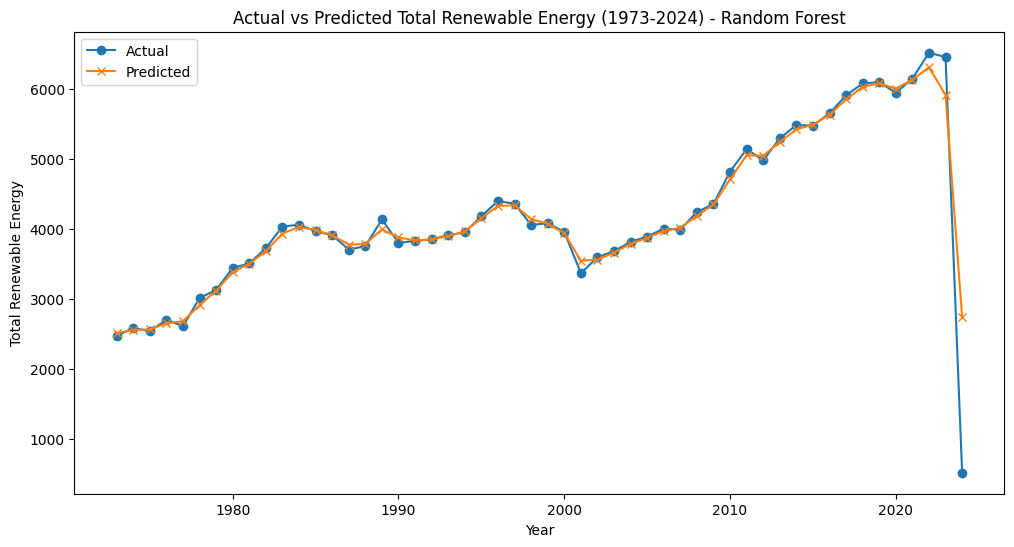

In [46]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
# Features and target
X = df_total[["Year"]]
y = df_total["Total Renewable Energy"]

# Train Random Forest model on full dataset
rf_model_full = RandomForestRegressor(n_estimators=300, random_state=42)
rf_model_full.fit(X, y)

# Predict on the same dataset (in-sample)
y_pred_full = rf_model_full.predict(X)

# Evaluate
mae = mean_absolute_error(y, y_pred_full)
rmse = np.sqrt(mean_squared_error(y, y_pred_full))
r2 = r2_score(y, y_pred_full)

print("Random Forest Results (1973–2024, Full Data):")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# make plot
plt.figure(figsize=(12,6))
plt.plot(df_total['Year'], y, label='Actual', marker='o')
plt.plot(df_total['Year'], y_pred_full, label='Predicted', marker='x')
plt.title('Actual vs Predicted Total Renewable Energy (1973-2024) - Random Forest')
plt.xlabel('Year')
plt.ylabel('Total Renewable Energy')
plt.legend()
plt.show()

### ARIMA

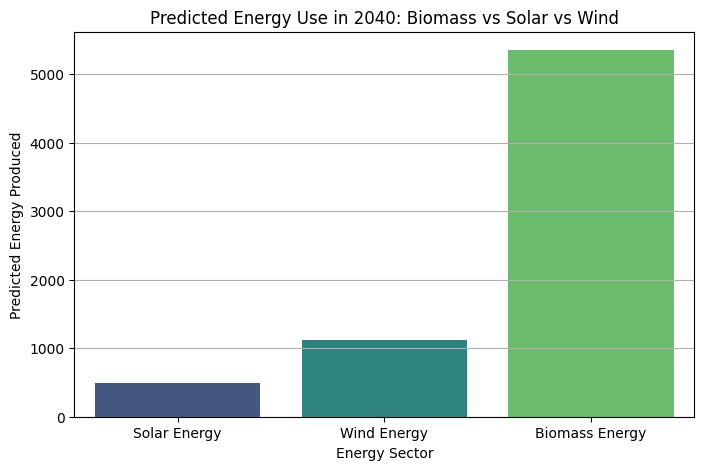

In [56]:

#""" # Predict Energy Source in year 2040 on top 

# Assuming df is your original dataset and energy_sectors is defined
energy_sectors1 = ['Solar Energy', 'Wind Energy', 'Biomass Energy']

# Group data by Year and sum energy use for relevant sectors
sector_yearly = df.groupby('Year')[energy_sectors1].sum().reset_index()

# Target year for forecast
target_year = 2040

# Store predictions for 2040
predictions_2040 = {}

for sector in energy_sectors1:
    X = sector_yearly[['Year']]
    y = sector_yearly[sector]

    model = LinearRegression()
    model.fit(X, y)

    forecast = model.predict([[target_year]])[0]
    predictions_2040[sector] = forecast

# Convert predictions to DataFrame for plotting
pred_2040_df = pd.DataFrame(list(predictions_2040.items()), columns=['Sector', 'Predicted_2040'])

# Plot bar chart of predicted energy use in 2040
plt.figure(figsize=(8, 5))
sns.barplot(data=pred_2040_df, x='Sector', y='Predicted_2040', palette='viridis')

plt.title('Predicted Energy Use in 2040: Biomass vs Solar vs Wind')
plt.ylabel('Predicted Energy Produced')
plt.xlabel('Energy Sector')
plt.grid(axis='y')
plt.show() #"""


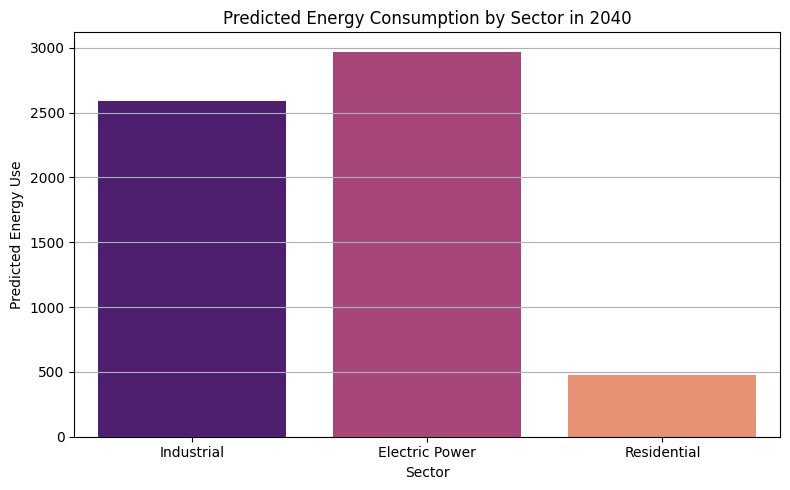


📊 In 2040, the sector with the highest predicted energy consumption is:
➡️  **Electric Power** with **2971.02 units**


In [64]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define your sector columns
consumption_sectors = ['Industrial', 'Electric Power', 'Residential']

# Pivot the data so each sector is a column, values are summed Total Renewable Energy
sector_yearly = df[df['Sector'].isin(consumption_sectors)].groupby(['Year', 'Sector'])['Total Renewable Energy'].sum().unstack().reset_index()

# Forecast target year
target_year = 2040

# Store predictions
predictions_2040 = {}

# Linear Regression for each sector
for sector in consumption_sectors:
    X = sector_yearly[['Year']]
    y = sector_yearly[sector]

    model = LinearRegression()
    model.fit(X, y)

    forecast = model.predict([[target_year]])[0]
    predictions_2040[sector] = forecast

# Create DataFrame for predictions
pred_2040_df = pd.DataFrame(list(predictions_2040.items()), columns=['Sector', 'Predicted_2040'])

# ---- Plotting ----
plt.figure(figsize=(8, 5))
sns.barplot(data=pred_2040_df, x='Sector', y='Predicted_2040', palette='magma')
plt.title('Predicted Energy Consumption by Sector in 2040')
plt.ylabel('Predicted Energy Use')
plt.xlabel('Sector')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ---- Print Highest Sector ----
top_sector = pred_2040_df.sort_values(by='Predicted_2040', ascending=False).iloc[0]
print(f"\n📊 In 2040, the sector with the highest predicted energy consumption is:")
print(f"➡️  **{top_sector['Sector']}** with **{top_sector['Predicted_2040']:.2f} units**")


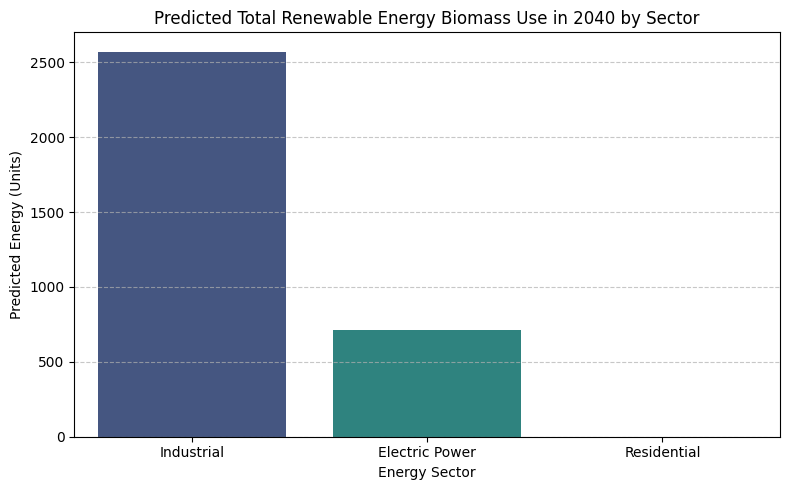

In [ ]:

""" # Predict Which Sector On Top in 2040 With Which energy Source 
# Define sectors to forecast
sectors_of_interest = ['Industrial','Electric Power','Residential']

# Dictionary to store predictions
predictions_2040 = {}
target_year = 2040

for sector in sectors_of_interest:
    # Filter for the sector
    sector_df = year_sector_source[year_sector_source['Sector'] == sector]
    
    # Features (Year) and Target (Total Renewable Energy consumption in that sector)
    X = sector_df[['Year']]
    y = sector_df['Biomass Energy']  # Change to 'Total Renewable Energy' if available e.g wind Energy,solar Energy, Hydro
    
    # Train linear regression
    model = LinearRegression()
    model.fit(X, y)
    
    # Forecast for 2040
    forecast = model.predict(np.array([[target_year]]))[0]
    predictions_2040[sector] = forecast

# Convert predictions to DataFrame for plotting
pred_2040_df = pd.DataFrame(list(predictions_2040.items()), columns=['Sector', 'Predicted_2040'])

# Plot bar chart of predicted energy use in 2040
plt.figure(figsize=(8, 5))
sns.barplot(data=pred_2040_df, x='Sector', y='Predicted_2040', palette='viridis')

plt.title('Predicted Total Renewable Energy Biomass Use in 2040 by Sector')
plt.ylabel('Predicted Energy (Units)')
plt.xlabel('Energy Sector')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()#"""
